In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

In [ ]:
from sklearn.pipeline import Pipeline

In [14]:
from xgboost import XGBRegressor
from sklearn.ensemble import BaggingRegressor, GradientBoostingRegressor, VotingRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [3]:
df = pd.read_csv('medical insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


#### **EDA**

In [6]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


Text(0.5, 1.0, 'Average Charges by Region')

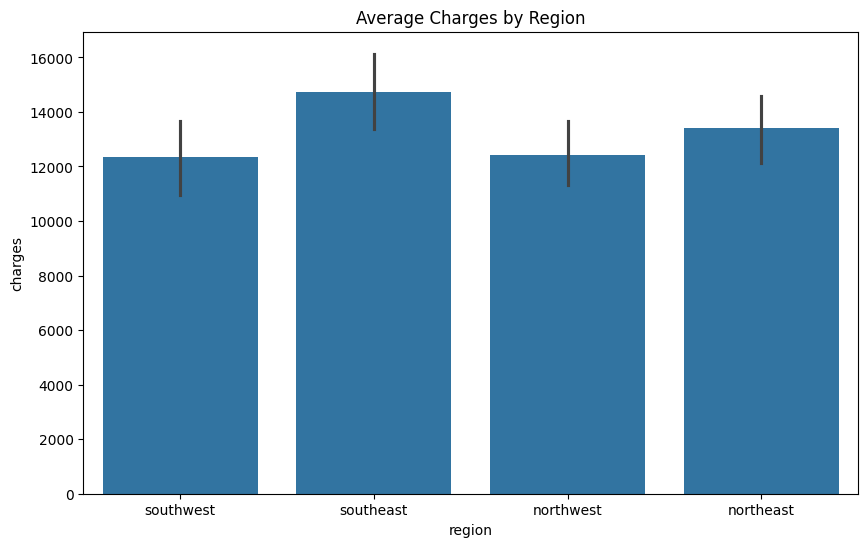

In [7]:
plt.figure(figsize=(10, 6))

sns.barplot(x='region', y='charges', data=df)

plt.title('Average Charges by Region')

here you see that **southeast** charges the most healthcare premium having an average of *15500*, followed by **northeast, then northwest and southwest**

Text(0.5, 1.0, 'Average Charges by Region on the basis of Gender')

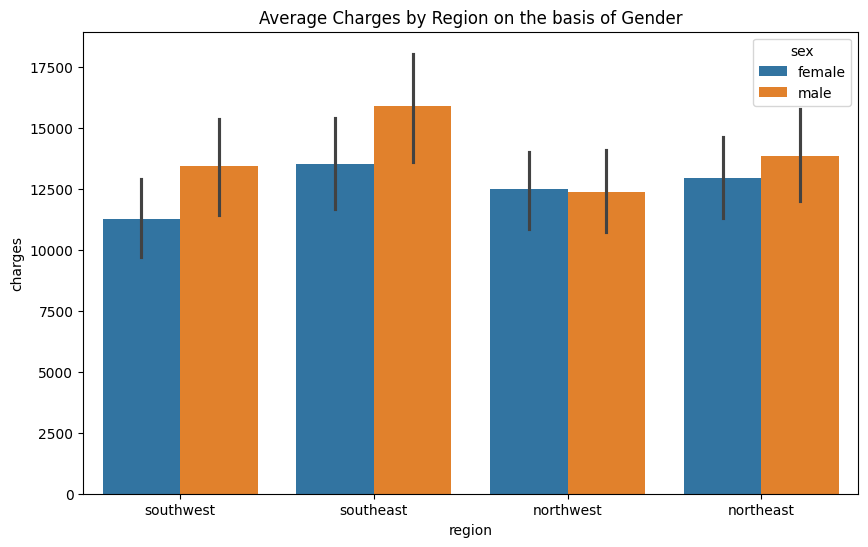

In [8]:
# lets create a visualization on the data on the basis of gender and region
plt.figure(figsize=(10, 6))
sns.barplot(x='region', y='charges', hue='sex', data=df)
plt.title('Average Charges by Region on the basis of Gender')

here you see male in souteast region have to charge the more premium as compare female, but in noethwest we see female have buy more premium as compare to male 

Text(0.5, 1.0, 'Average Charges by Region for male who smoke and who do not smoke')

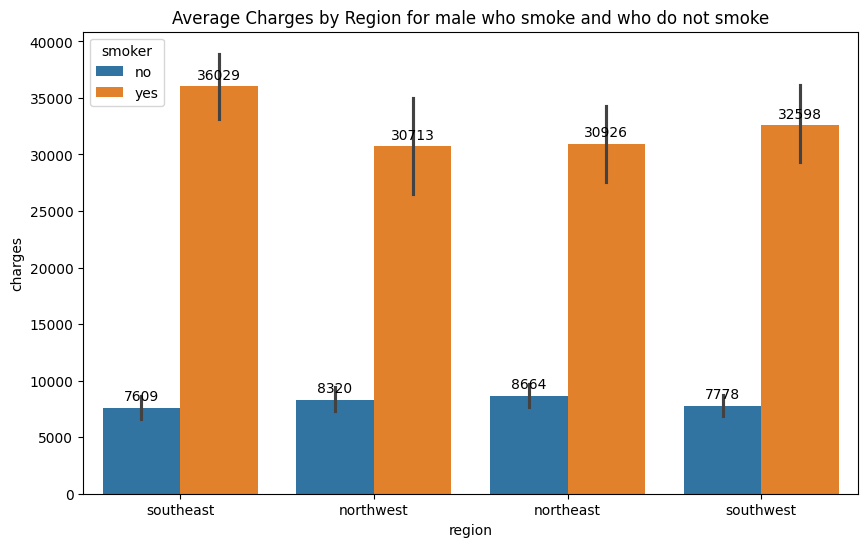

In [9]:
# lets compare the males who smoke and who do not smoke from differnt region and how much in average they are charged
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='region', y='charges', hue='smoker', data=df[df['sex'] == 'male'],)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', padding=3)
plt.title('Average Charges by Region for male who smoke and who do not smoke') 

- in the above plot we could see that most of the male who smoke charges nearly five time more premium than the non smokers in the southesat region
- In the northwest region smokers pay nearly 4 times more payment than non smokers
- In the northeast region smokers pay nearly 4 times more payment than non smokers
- In the Southwest region smokers pay nearly 5 time more payment than non smokers

Text(0.5, 1.0, 'Average Charges by Region for female who smoke and who do not smoke')

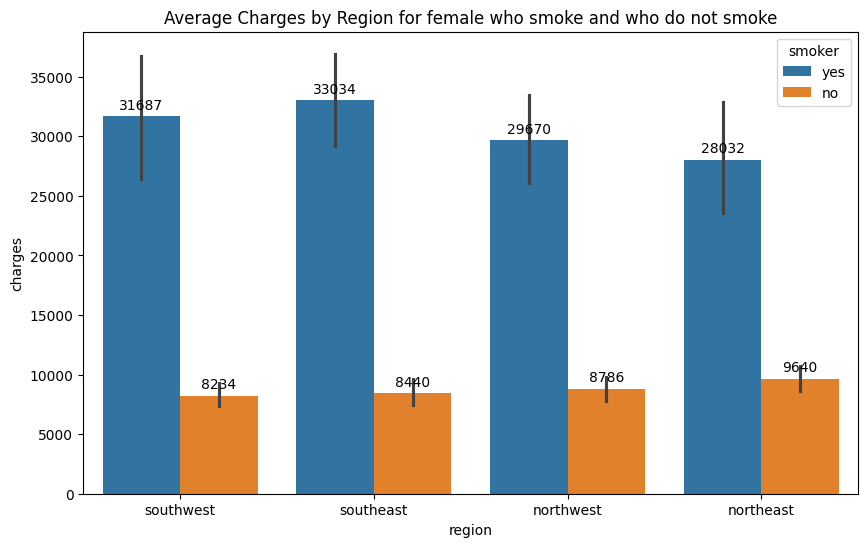

In [10]:
# lets compare the females who smoke and who do not smoke from differnt region and how much in average they are charged
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='region', y='charges', hue='smoker', data=df[df['sex'] == 'female'])
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', padding=3)
plt.title('Average Charges by Region for female who smoke and who do not smoke')       

- here those females who smoke are mainly the one who pays the premium more as compare to non somkers like nearly 5 times the non smokers

Text(0.5, 1.0, 'Average Charges by smokers on different gender')

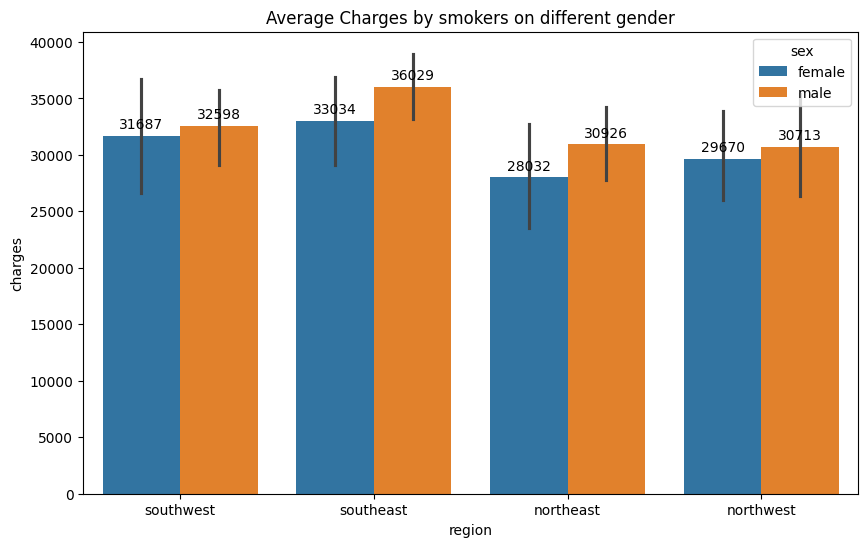

In [11]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='region', y='charges', hue='sex', data=df[df['smoker'] == 'yes'])
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', padding=3)
plt.title('Average Charges by smokers on different gender')

- here above we could see that mens pay more premium as compare to female and southeast region pays the highest and northeast pays lowest

#### Now 

#### **feature engineering and feature scaling**

In [ ]:

categorical_features = ["sex", "smoker", "region"]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(drop='first', handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

X_processed = preprocessor.fit_transform(df)
X_processed

array([[1.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        2.79000000e+01, 0.00000000e+00, 1.68849240e+04],
       [0.00000000e+00, 1.00000000e+00, 1.00000000e+00, ...,
        3.37700000e+01, 1.00000000e+00, 1.72555230e+03],
       [0.00000000e+00, 1.00000000e+00, 1.00000000e+00, ...,
        3.30000000e+01, 3.00000000e+00, 4.44946200e+03],
       ...,
       [1.00000000e+00, 0.00000000e+00, 1.00000000e+00, ...,
        3.68500000e+01, 0.00000000e+00, 1.62983350e+03],
       [1.00000000e+00, 0.00000000e+00, 1.00000000e+00, ...,
        2.58000000e+01, 0.00000000e+00, 2.00794500e+03],
       [1.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        2.90700000e+01, 0.00000000e+00, 2.91413603e+04]], shape=(1338, 12))

In [7]:
df['region'].unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

In [8]:
mapping_sex = {'female': 1, 'male': 0}
mapping_smoker = {'yes': 1, 'no': 0}
mapping_region = {'southeast': 0, 'southwest': 1, 'northeast': 2, 'northwest': 3}

In [9]:
df['sex'] = df['sex'].map(mapping_sex)
df['sex']

0       1
1       0
2       0
3       0
4       0
       ..
1333    0
1334    1
1335    1
1336    1
1337    1
Name: sex, Length: 1338, dtype: int64

In [10]:
df['smoker'] = df['smoker'].map(mapping_smoker)
df['region'] =df['region'].map(mapping_region)
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,1,16884.92400
1,18,0,33.770,1,0,0,1725.55230
2,28,0,33.000,3,0,0,4449.46200
3,33,0,22.705,0,0,3,21984.47061
4,32,0,28.880,0,0,3,3866.85520


here we could see that I have encoded the data like **sex, smoker, region** are into ```integer``` which makes it easier for us to make it easier for them

In [11]:
# let's now check whether there is any missing valus or not
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Text(0.5, 1.0, 'Correlation Matrix')

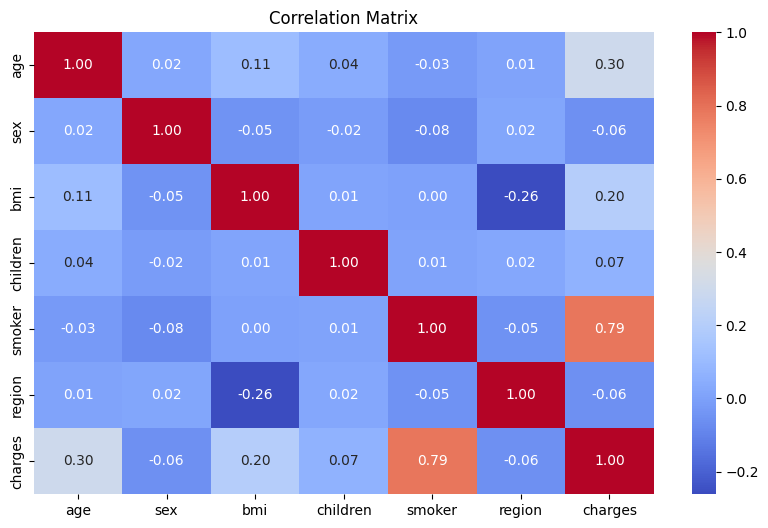

In [13]:
# now lets see there correlatio beteween the other variables
features = df.drop('charges', axis=1)
target = df['charges']

correlation_matrix = df.corr()
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')

Text(0.5, 1.0, 'Correlation Matrix with Charges')

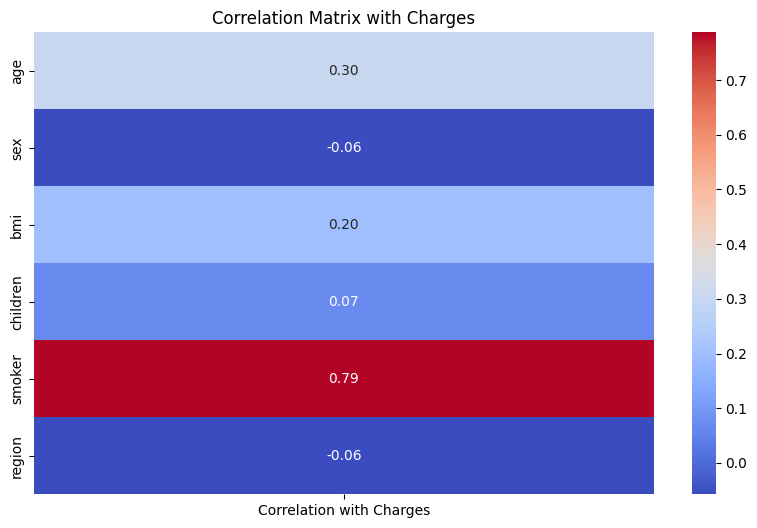

In [ ]:
# correlation with features and target variable
target_corr = features.corrwith(target)
target_corr_df  = target_corr.to_frame(name = 'Correlation with Charges')

# lets create a heat map on this data
plt.figure(figsize=(10, 6))
sns.heatmap(target_corr_df, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix with Charges')

#### Find the outliers and missing values

In [15]:
def create_box_plot_seaborn(data, column_name):
    """Generates a box plot using Seaborn."""

    plt.figure(figsize=(12, 6)) # Adjust figure size as needed

    sns.boxplot(data=data, x=data[column_name])  # Use seaborn's built-in boxplot function
    plt.title(f"Box Plot of {column_name}")
    plt.ylabel("Feature")
    plt.xlabel("Value")
    plt.tight_layout()  # Adjust layout to prevent labels from overlapping
    plt.show()

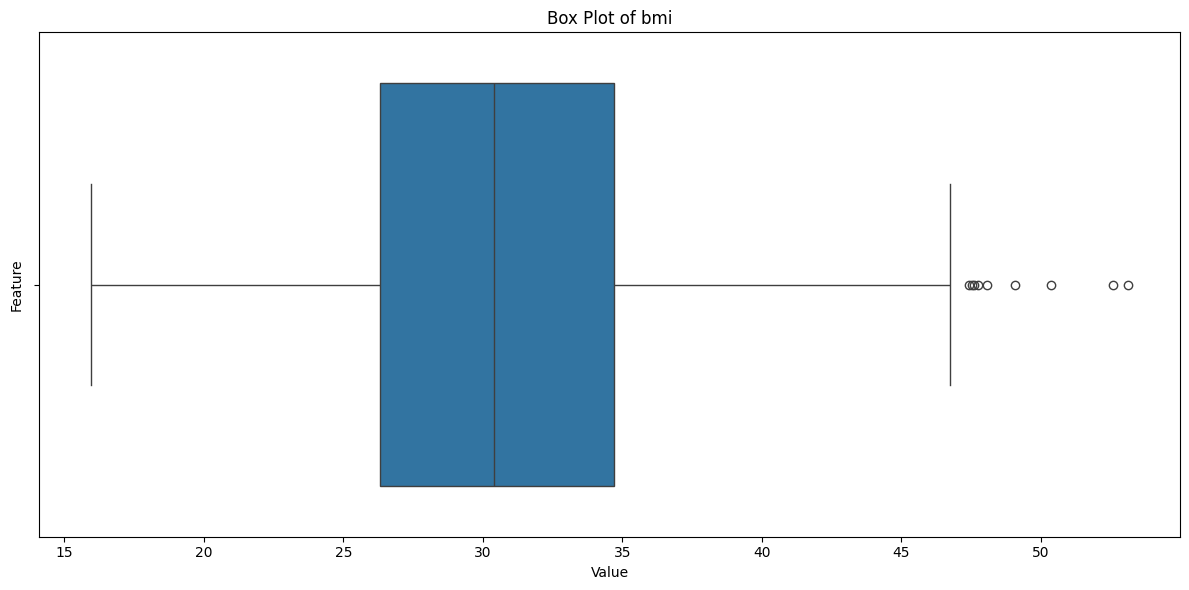

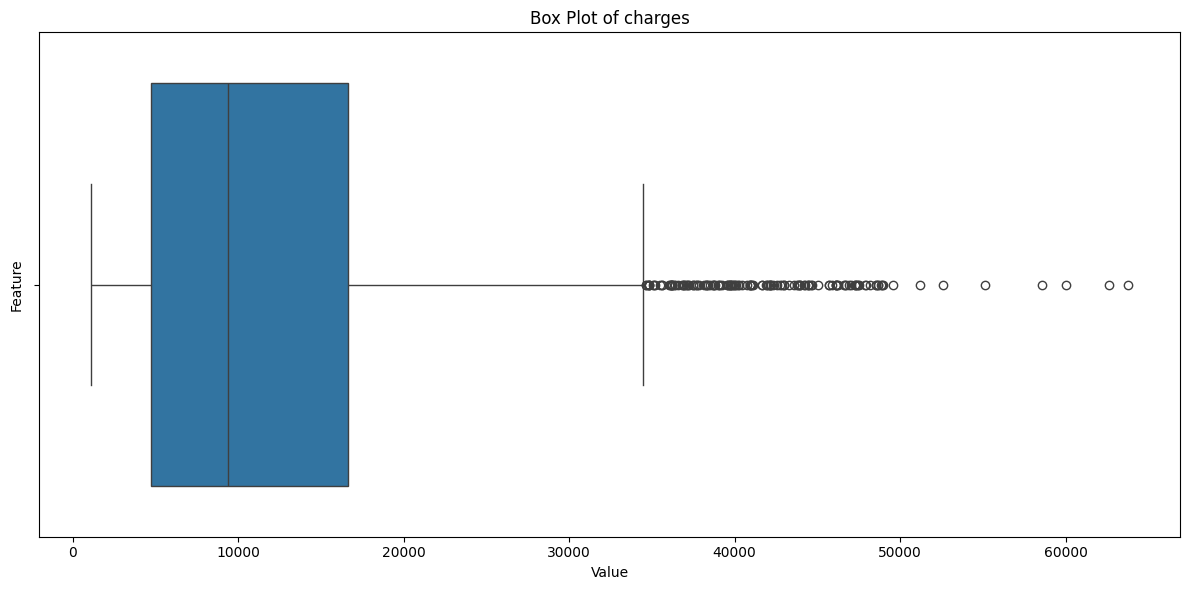

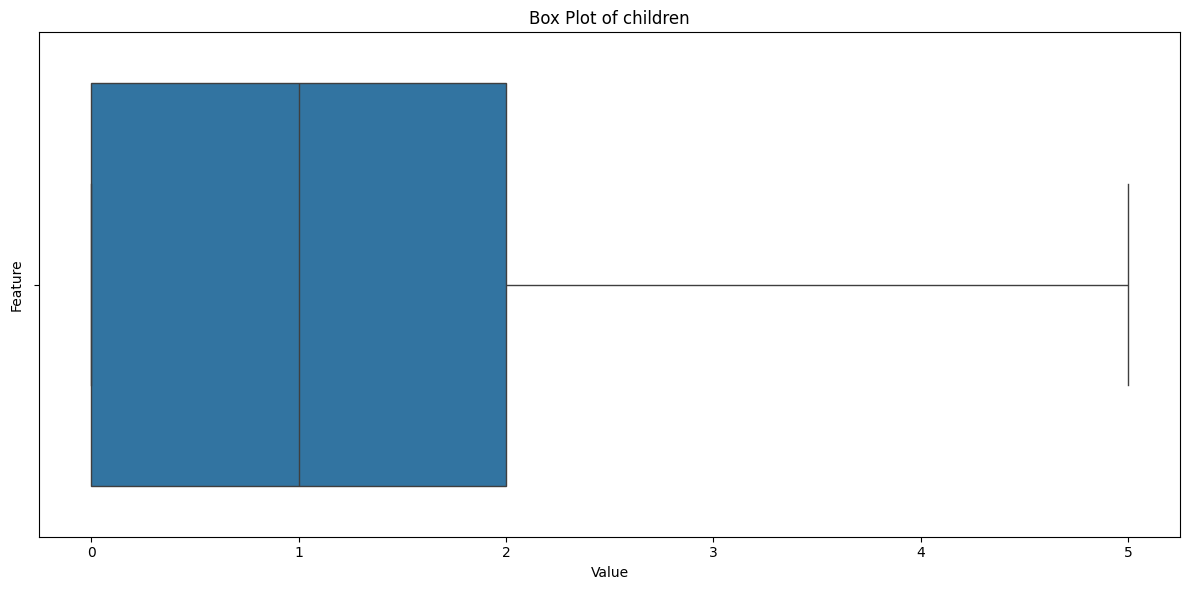

In [16]:
create_box_plot_seaborn(df, 'bmi')
create_box_plot_seaborn(df, 'charges')
create_box_plot_seaborn(df, 'children')

In [17]:
def check_skewness(data):
    """Checks and reports the skewness of the data."""

    # Calculate the mean and standard deviation of the data.  Handle potential errors.
    try:
        mean = data.mean()
        std = data.std()
    except Exception as e:
        print(f"Error calculating statistics: {e}")
        return None

    # Calculate skewness using the formula (can be adjusted for accuracy).  The value 2.0 is a common default.
    skewness = np.mean((data - mean) / std)
    
    if skewness < 0:
        print("Data has positive skewness.")
    elif skewness > 1: #  Added this check for greater than one
        print("Data has excessive skewness.")
    else:
        print(f"Skewness: {skewness}")

    return skewness

In [18]:
if __name__ == "__main__":

    try:
        skewness_value = check_skewness(df)
        if skewness_value is not None:
            print(f"Skewness: {skewness_value}")
    except Exception as e:
        print(f"An error occurred: {e}")

Data has positive skewness.
Skewness: -4.0397609095905763e-17


In [36]:
# here now we will do the log transformation on the target variable to reduce the skewness
df['log_charges'] = np.log(df['charges'])
df.head()

,age,sex,bmi,children,smoker,region,charges,log_charges
0,19,1,27.900,0,1,1,16884.92400,9.734176
1,18,0,33.770,1,0,0,1725.55230,7.453302
2,28,0,33.000,3,0,0,4449.46200,8.400538
3,33,0,22.705,0,0,3,21984.47061,9.998092
4,32,0,28.880,0,0,3,3866.85520,8.260197


#### lets do without scaling

In [20]:
X = df.drop(columns=['charges'])
y = df['charges']
train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.2, random_state=42)

In [47]:
# here we will save the performance matrix
model_name = []
training_score_r2 =  []
training_score_mae = []
training_score_rmse = []
training_score_mse = []
training_score_abs_r2 = []

test_score_r2 = []
test_score_mae = []
test_score_rmse = []
test_score_mse = []
test_score_abs_r2 = []
metrics = []

In [48]:
def evaluate_models(model, train_X, test_X,train_y, test_y,):

    model.fit(train_X, train_y)

    test_pred_y = model.predict(test_X)
    train_pred_y = model.predict(train_X)

    #calculate the R2 score for both training and testing data
    train_r2 = r2_score(train_y, train_pred_y) * 100
    test_r2 = r2_score(test_y, test_pred_y) * 100

    #calculate adjusted R2 score for both training and testing data
    n_train, p_train = train_X.shape
    n_test, p_test = test_X.shape
    test_adj_r2 = (1 - (1 - test_r2/100) * (n_test - 1) / (n_test - p_test - 1)) * 100
    train_adj_r2 = (1 - (1 - train_r2/100) * (n_train - 1) / (n_train - p_train - 1)) * 100

    # Calculate MSE, RSME, and MAE for both training and tresting data
    train_mse = mean_squared_error(train_y, train_pred_y)
    test_mse = mean_squared_error(test_y, test_pred_y)

    test_rmse = np.sqrt(test_mse)
    train_rmse = np.sqrt(train_mse)

    train_mae = mean_absolute_error(train_y, train_pred_y)
    test_mae = mean_absolute_error(test_y, test_pred_y)

    training_score_r2.append(train_r2)
    training_score_mae.append(train_mae)
    training_score_rmse.append(train_rmse)
    training_score_mse.append(train_mse)
    training_score_abs_r2.append(train_adj_r2)

    test_score_r2.append(test_r2)
    test_score_mae.append(test_mae)
    test_score_rmse.append(test_rmse)
    test_score_mse.append(test_mse)
    test_score_abs_r2.append(test_adj_r2)
    
    model_name.append(model.__class__.__name__)

    print(f"{model.__class__.__name__} Performance:")
    print(f"Training R2 Score: {train_r2:.2f}%, Adjusted R2 Score: {train_adj_r2:.2f}%, RMSE: {train_rmse:.2f}, MAE: {train_mae:.2f}")
    print(f"Testing R2 Score: {test_r2:.2f}%, Adjusted R2 Score: {test_adj_r2:.2f}%, RMSE: {test_rmse:.2f}, MAE: {test_mae:.2f}")

    return {
        'model_name': model.__class__.__name__,
        'train_r2': train_r2,
        'train_adj_r2': train_adj_r2,
        'train_rmse': train_rmse,
        'train_mae': train_mae,
        'test_r2': test_r2,
        'test_adj_r2': test_adj_r2,
        'test_rmse': test_rmse,
        'test_mae': test_mae
    }

    

In [49]:
# model evaluation by linear regression without scaling
metrics.append(evaluate_models(LinearRegression(), train_X=train_X, test_X=test_X,train_y=train_y, test_y=test_y))
#model evaluation by ridge without scaling
metrics.append(evaluate_models(Ridge(alpha=0.1, random_state=42), train_X=train_X, test_X=test_X, train_y=train_y, test_y=test_y))
#model evaluation by lasso regression without scaling
metrics.append(evaluate_models(Lasso(alpha=1, random_state=42), train_X=train_X, test_X=test_X, train_y=train_y, test_y=test_y))
# model evaluation by Decsion Tree without scaling
metrics.append(evaluate_models(DecisionTreeRegressor(ccp_alpha= 10, random_state=42), train_X=train_X, test_X=test_X, train_y=train_y, test_y=test_y))
# model evaluation by random Forest without scaling
metrics.append(evaluate_models(RandomForestRegressor(random_state=42), train_X=train_X, test_X=test_X, train_y=train_y, test_y=test_y))

LinearRegression Performance:
Training R2 Score: 74.13%, Adjusted R2 Score: 73.99%, RMSE: 6110.42, MAE: 4214.90
Testing R2 Score: 78.30%, Adjusted R2 Score: 77.80%, RMSE: 5803.93, MAE: 4190.22
Ridge Performance:
Training R2 Score: 74.13%, Adjusted R2 Score: 73.99%, RMSE: 6110.42, MAE: 4215.87
Testing R2 Score: 78.30%, Adjusted R2 Score: 77.80%, RMSE: 5804.30, MAE: 4191.50
Lasso Performance:
Training R2 Score: 74.13%, Adjusted R2 Score: 73.99%, RMSE: 6110.42, MAE: 4215.23
Testing R2 Score: 78.30%, Adjusted R2 Score: 77.80%, RMSE: 5804.35, MAE: 4191.07
DecisionTreeRegressor Performance:
Training R2 Score: 99.83%, Adjusted R2 Score: 99.83%, RMSE: 494.69, MAE: 39.65
Testing R2 Score: 67.48%, Adjusted R2 Score: 66.73%, RMSE: 7105.42, MAE: 3350.37
RandomForestRegressor Performance:
Training R2 Score: 97.42%, Adjusted R2 Score: 97.41%, RMSE: 1928.88, MAE: 1057.50
Testing R2 Score: 86.66%, Adjusted R2 Score: 86.35%, RMSE: 4551.41, MAE: 2506.31


In [50]:
model_eval = pd.DataFrame(metrics)

model_eval

,model_name,train_r2,train_adj_r2,train_rmse,train_mae,test_r2,test_adj_r2,test_rmse,test_mae
0,LinearRegression,74.131312,73.985299,6110.418514,4214.897445,78.302159,77.803358,5803.931715,4190.220190
1,Ridge,74.131291,73.985278,6110.420987,4215.865280,78.299430,77.800566,5804.296677,4191.495791
2,Lasso,74.131303,73.985290,6110.419562,4215.226516,78.299025,77.800152,5804.350787,4191.065718
3,DecisionTreeRegressor,99.830448,99.829491,494.692350,39.648420,67.479965,66.732378,7105.416322,3350.367922
4,RandomForestRegressor,97.422242,97.407693,1928.878132,1057.497325,86.656657,86.349913,4551.414216,2506.307244


these are done without scaling, here we could also see different algorithms:

- Linear Regression : here above the model gives training absolute R2 73.985% and testing absolute R2 at 77.80 so its giving good result in the test dataset
- Ridge Regession : here above the model gives training absolute R2 73.985% and testing absolute R2 at 77.80 so its giving good result in the test dataset
- Lasso Regession : here above the model gives training absolute R2 73.985% and testing absolute R2 at 77.80 so its giving good result in the test dataset
- Decision Tree Regessor : here above the model gives training absolute R2 99.82% and testing absolute R2 at 66.73 so its giving bad result in the test dataset this might be due to overfitting with the data
- Random Forest Regressor : here above the model gives training absolute R2 97.40% and testing absolute R2 at 86.34 so its giving bad result with the test dataset because it's giving an overfitting with the data

 

#### now lets do it by scaling the data

In [51]:
# here we will save the performance matrix
model_name = []
training_score_r2 =  []
training_score_mae = []
training_score_rmse = []
training_score_mse = []
training_score_abs_r2 = []

test_score_r2 = []
test_score_mae = []
test_score_rmse = []
test_score_mse = []
test_score_abs_r2 = []
metrics = []

In [ ]:
X = df.drop(columns=['charges'])
y = df['charges']

train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.2, random_state=42)   

In [53]:
Scalar = StandardScaler()
Std_scale_trained_X = Scalar.fit_transform(train_X)
Std_scale_test_X = Scalar.transform(test_X)


In [55]:
#model evaluation by linear regression with scaling
metrics.append(evaluate_models(model= LinearRegression(),train_X = Std_scale_trained_X,test_X = Std_scale_test_X, train_y = train_y, test_y = test_y))
#model evaluation by ridge with scaling
metrics.append(evaluate_models(Ridge(alpha=0.1, random_state=42), train_X = Std_scale_trained_X,test_X= Std_scale_test_X, train_y = train_y, test_y = test_y))
#model evaluation by lasso regression with scaling
metrics.append(evaluate_models(Lasso(alpha=1, random_state=42), train_X=Std_scale_trained_X, test_X = Std_scale_test_X, train_y = train_y, test_y = test_y))
# model evaluation by Decsion Tree with scaling
metrics.append(evaluate_models(DecisionTreeRegressor(ccp_alpha= 10, random_state=42), train_X=Std_scale_trained_X, test_X = Std_scale_test_X, train_y = train_y, test_y = test_y))
# model evaluation by random Forest with scaling
metrics.append(evaluate_models(RandomForestRegressor(random_state=42), train_X=Std_scale_trained_X, test_X = Std_scale_test_X, train_y = train_y, test_y = test_y))

LinearRegression Performance:
Training R2 Score: 74.13%, Adjusted R2 Score: 73.99%, RMSE: 6110.42, MAE: 4214.90
Testing R2 Score: 78.30%, Adjusted R2 Score: 77.80%, RMSE: 5803.93, MAE: 4190.22
Ridge Performance:
Training R2 Score: 74.13%, Adjusted R2 Score: 73.99%, RMSE: 6110.42, MAE: 4215.01
Testing R2 Score: 78.30%, Adjusted R2 Score: 77.80%, RMSE: 5804.00, MAE: 4190.39
Lasso Performance:
Training R2 Score: 74.13%, Adjusted R2 Score: 73.99%, RMSE: 6110.42, MAE: 4214.77
Testing R2 Score: 78.30%, Adjusted R2 Score: 77.80%, RMSE: 5804.24, MAE: 4190.47
DecisionTreeRegressor Performance:
Training R2 Score: 99.83%, Adjusted R2 Score: 99.83%, RMSE: 494.69, MAE: 39.65
Testing R2 Score: 68.14%, Adjusted R2 Score: 67.41%, RMSE: 7032.78, MAE: 3277.63
RandomForestRegressor Performance:
Training R2 Score: 97.44%, Adjusted R2 Score: 97.42%, RMSE: 1923.48, MAE: 1054.00
Testing R2 Score: 86.71%, Adjusted R2 Score: 86.41%, RMSE: 4541.61, MAE: 2500.10


In [56]:
model_scalled_eval = pd.DataFrame(metrics)

model_scalled_eval

,model_name,train_r2,train_adj_r2,train_rmse,train_mae,test_r2,test_adj_r2,test_rmse,test_mae
0,LinearRegression,74.131312,73.985299,6110.418514,4214.897445,78.302159,77.803358,5803.931715,4190.220190
1,Ridge,74.131311,73.985298,6110.418594,4215.011889,78.301662,77.802850,5803.998135,4190.394530
2,Lasso,74.131307,73.985294,6110.419056,4214.773173,78.299890,77.801037,5804.235133,4190.474467
3,DecisionTreeRegressor,99.830448,99.829491,494.692350,39.648420,68.141458,67.409077,7032.779184,3277.629041
4,RandomForestRegressor,97.436650,97.422181,1923.480205,1054.000560,86.714095,86.408672,4541.607503,2500.097556


Even though used standard scaler in the data still there was no difference in train and test accuracy in the model 

let's try using minmax scalar

In [ ]:
#now let's check the decision tree algorithm with randomSearchCV and Grid searchcv
def grid_search(X,y):
    '''here we will perform grid search cross valiadation where we will find the best fit for the data on Decision tree algo'''
    param_grid = {
        'max_depth': [None, 3, 5, 7],  # None means no limit
        'min_samples_split': [2, 4, 6, 8],
        'min_samples_leaf': [1, 2, 3, 4]
    }

    grid = GridSearchCV(DecisionTreeRegressor(), param_grid, cv=5, scoring='r2') # Use negative MSE for optimization
    grid.fit(X, y)
    print("GridSearchCV Results:")
    print("Best Parameters:", grid.best_params_)
    print("Best Score (r2 score):", grid.best_score_)
    print("Best Model:", grid.best_estimator_)

grid_search(train_X, train_y)


GridSearchCV Results:
Best Parameters: {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best Score (Negative Mean Squared Error): 0.8356879686154602
Best Model: DecisionTreeRegressor(max_depth=3)


In [42]:
# --- RandomizedSearchCV Example ---
def random_search_cv(X, y):
    """Performs RandomizedSearchCV for DecisionTreeRegressor."""

    param_distributions = {
        'max_depth': ['None', 3, 5, 7],  # Define the possible values for each parameter
        'min_samples_split': [2, 4, 6, 8],
        'min_samples_leaf': [1, 2, 3, 4]
    }

    random = RandomizedSearchCV(DecisionTreeRegressor(), param_distributions, cv=5, n_iter=10, scoring='r2') # Use negative MSE
    random.fit(X, y)
    print("\nRandomizedSearchCV Results:")
    print("Best Parameters:", random.best_params_)
    print("Best Score (Negative Mean Squared Error):", random.best_score_)
    print("Best Model:", random.best_estimator_)


random_search_cv(train_X, train_y)



RandomizedSearchCV Results:
Best Parameters: {'min_samples_split': 8, 'min_samples_leaf': 4, 'max_depth': 3}
Best Score (Negative Mean Squared Error): 0.8356879686154602
Best Model: DecisionTreeRegressor(max_depth=3, min_samples_leaf=4, min_samples_split=8)


d:\ML_deployment\myenv\lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
15 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
15 fits failed with the following error:
Traceback (most recent call last):
  File "d:\ML_deployment\myenv\lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "d:\ML_deployment\myenv\lib\site-packages\sklearn\base.py", line 1358, in wrapper
    estimator._validate_params()
  File "d:\ML_deployment\myenv\lib\site-packages\sklearn\base.py", line 471, in _validate_params
    validate_parameter_constraints(
  File "d:\ML_deployment\myenv\lib\site-packages\sklearn\ut

In [57]:
metrics.append(evaluate_models(DecisionTreeRegressor(max_depth=3),train_X=train_X, test_X=test_X, train_y = train_y, test_y = test_y))

DecisionTreeRegressor Performance:
Training R2 Score: 85.37%, Adjusted R2 Score: 85.28%, RMSE: 4595.69, MAE: 2785.25
Testing R2 Score: 85.31%, Adjusted R2 Score: 84.97%, RMSE: 4776.26, MAE: 2865.64


after doing with Gridsearch cv and random forest cv I found the best fit i.e R2 Score: 85.37% on training data and 85.31% on testing dataset

Where the Decision Tree Regressor does well when Decision Tree Regressor having max depth of 3 

In [58]:
# --- Linear Regression GridSearchCV ---
def linear_grid_search_cv(X, y):
    """Performs GridSearchCV for LinearRegression."""

    param_grid = {
        'fit_intercept': [True, False]  # Whether to include an intercept term
    }

    grid = GridSearchCV(LinearRegression(), param_grid, cv=5, scoring='neg_mean_squared_error')
    grid.fit(X, y)
    print("Linear Regression GridSearchCV Results:")
    print("Best Parameters:", grid.best_params_)
    print("Best Score (Negative Mean Squared Error):", grid.best_score_)
    print("Best Model:", grid.best_estimator_)


# --- Ridge Regression GridSearchCV ---
def ridge_grid_search_cv(X, y):
    """Performs GridSearchCV for RidgeRegression."""

    param_grid = {
        'alpha': [0.01, 0.1, 1, 10, 100] # Regularization strength (C parameter)
    }

    grid = GridSearchCV(Ridge(), param_grid, cv=5, scoring='neg_mean_squared_error')
    grid.fit(X, y)
    print("\nRidge Regression GridSearchCV Results:")
    print("Best Parameters:", grid.best_params_)
    print("Best Score (Negative Mean Squared Error):", grid.best_score_)
    print("Best Model:", grid.best_estimator_)



# --- Lasso Regression GridSearchCV ---
def lasso_grid_search_cv(X, y):
    """Performs GridSearchCV for LassoRegression."""

    param_grid = {
        'alpha': [0.01, 0.1, 1, 10, 100]  # Regularization strength (C parameter)
    }

    grid = GridSearchCV(Lasso(), param_grid, cv=5, scoring='neg_mean_squared_error')
    grid.fit(X, y)
    print("\nLasso Regression GridSearchCV Results:")
    print("Best Parameters:", grid.best_params_)
    print("Best Score (Negative Mean Squared Error):", grid.best_score_)
    print("Best Model:", grid.best_estimator_)

In [59]:
metrics.append(linear_grid_search_cv(train_X, train_y))

metrics.append(ridge_grid_search_cv(train_X, train_y))

metrics.append(lasso_grid_search_cv(train_X,train_y))

Linear Regression GridSearchCV Results:
Best Parameters: {'fit_intercept': True}
Best Score (Negative Mean Squared Error): -37868169.435521066
Best Model: LinearRegression()

Ridge Regression GridSearchCV Results:
Best Parameters: {'alpha': 0.1}
Best Score (Negative Mean Squared Error): -37867695.53652337
Best Model: Ridge(alpha=0.1)

Lasso Regression GridSearchCV Results:
Best Parameters: {'alpha': 100}
Best Score (Negative Mean Squared Error): -37793033.66246521
Best Model: Lasso(alpha=100)


In [60]:
metrics.append(evaluate_models(model=Lasso(alpha=100),train_X=train_X, train_y=train_y, test_X=test_X, test_y = test_y))

Lasso Performance:
Training R2 Score: 74.08%, Adjusted R2 Score: 73.93%, RMSE: 6116.85, MAE: 4253.40
Testing R2 Score: 78.02%, Adjusted R2 Score: 77.52%, RMSE: 5840.99, MAE: 4258.87


In [ ]:
result = evaluate_models(XGBRegressor(objective='reg:squarederror',n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42), train_X=train_X, train_y = train_y, test_X= test_X, test_y = test_y)

model_eval = pd.concat([model_eval, pd.DataFrame([result])])
model_eval

XGBRegressor Performance:
Training R2 Score: 89.27%, Adjusted R2 Score: 89.21%, RMSE: 3936.11, MAE: 2153.83
Testing R2 Score: 88.38%, Adjusted R2 Score: 88.12%, RMSE: 4246.90, MAE: 2399.92


,model_name,train_r2,train_adj_r2,train_rmse,train_mae,test_r2,test_adj_r2,test_rmse,test_mae
0,LinearRegression,74.131312,73.985299,6110.418514,4214.897445,78.302159,77.803358,5803.931715,4190.220190
1,Ridge,74.131291,73.985278,6110.420987,4215.865280,78.299430,77.800566,5804.296677,4191.495791
2,Lasso,74.131303,73.985290,6110.419562,4215.226516,78.299025,77.800152,5804.350787,4191.065718
3,DecisionTreeRegressor,99.830448,99.829491,494.692350,39.648420,67.479965,66.732378,7105.416322,3350.367922
4,RandomForestRegressor,97.422242,97.407693,1928.878132,1057.497325,86.656657,86.349913,4551.414216,2506.307244
0,XGBRegressor,89.265862,89.205274,3936.110992,2153.831922,88.382388,88.115317,4246.904168,2399.919204


In [68]:
model_eval.reset_index()

,index,model_name,train_r2,train_adj_r2,train_rmse,train_mae,test_r2,test_adj_r2,test_rmse,test_mae
0,0,LinearRegression,74.131312,73.985299,6110.418514,4214.897445,78.302159,77.803358,5803.931715,4190.220190
1,1,Ridge,74.131291,73.985278,6110.420987,4215.865280,78.299430,77.800566,5804.296677,4191.495791
2,2,Lasso,74.131303,73.985290,6110.419562,4215.226516,78.299025,77.800152,5804.350787,4191.065718
3,3,DecisionTreeRegressor,99.830448,99.829491,494.692350,39.648420,67.479965,66.732378,7105.416322,3350.367922
4,4,RandomForestRegressor,97.422242,97.407693,1928.878132,1057.497325,86.656657,86.349913,4551.414216,2506.307244
5,0,XGBRegressor,89.265862,89.205274,3936.110992,2153.831922,88.382388,88.115317,4246.904168,2399.919204


In [71]:
model_eval

,model_name,train_r2,train_adj_r2,train_rmse,train_mae,test_r2,test_adj_r2,test_rmse,test_mae
0,LinearRegression,74.131312,73.985299,6110.418514,4214.897445,78.302159,77.803358,5803.931715,4190.220190
1,Ridge,74.131291,73.985278,6110.420987,4215.865280,78.299430,77.800566,5804.296677,4191.495791
2,Lasso,74.131303,73.985290,6110.419562,4215.226516,78.299025,77.800152,5804.350787,4191.065718
3,DecisionTreeRegressor,99.830448,99.829491,494.692350,39.648420,67.479965,66.732378,7105.416322,3350.367922
4,RandomForestRegressor,97.422242,97.407693,1928.878132,1057.497325,86.656657,86.349913,4551.414216,2506.307244
0,XGBRegressor,89.265862,89.205274,3936.110992,2153.831922,88.382388,88.115317,4246.904168,2399.919204


In [ ]:
# now we will use bagging  regressor for regression and second is the gradient boost regression
result = []
metric = evaluate_models(BaggingRegressor(estimator= LinearRegression(), n_estimators=10, random_state =42), train_X=train_X, test_X = test_X, train_y = train_y, test_y = test_y)
result.append(metric)

model_eval = pd.concat([model_eval, pd.DataFrame([result])], ignore_index= True)
model_eval

BaggingRegressor Performance:
Training R2 Score: 74.11%, Adjusted R2 Score: 73.96%, RMSE: 6112.92, MAE: 4172.14
Testing R2 Score: 78.41%, Adjusted R2 Score: 77.91%, RMSE: 5789.90, MAE: 4125.02


,model_name,train_r2,train_adj_r2,train_rmse,train_mae,test_r2,test_adj_r2,test_rmse,test_mae,0,1
0,LinearRegression,74.131312,73.985299,6110.418514,4214.897445,78.302159,77.803358,5803.931715,4190.220190,NaN,NaN
1,Ridge,74.131291,73.985278,6110.420987,4215.865280,78.299430,77.800566,5804.296677,4191.495791,NaN,NaN
2,Lasso,74.131303,73.985290,6110.419562,4215.226516,78.299025,77.800152,5804.350787,4191.065718,NaN,NaN
3,DecisionTreeRegressor,99.830448,99.829491,494.692350,39.648420,67.479965,66.732378,7105.416322,3350.367922,NaN,NaN
4,RandomForestRegressor,97.422242,97.407693,1928.878132,1057.497325,86.656657,86.349913,4551.414216,2506.307244,NaN,NaN
5,XGBRegressor,89.265862,89.205274,3936.110992,2153.831922,88.382388,88.115317,4246.904168,2399.919204,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{'model_name': 'BaggingRegressor', 'train_r2':...","{'model_name': 'GradientBoostingRegressor', 't..."
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{'model_name': 'BaggingRegressor', 'train_r2':...",NaN


In [81]:
metric = evaluate_models(GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42), train_X=train_X, test_X = test_X, train_y = train_y, test_y = test_y)


model_eval = pd.concat([model_eval, pd.DataFrame([result])])
model_eval

GradientBoostingRegressor Performance:
Training R2 Score: 92.50%, Adjusted R2 Score: 92.46%, RMSE: 3289.46, MAE: 1800.54
Testing R2 Score: 86.88%, Adjusted R2 Score: 86.58%, RMSE: 4513.13, MAE: 2497.85


,model_name,train_r2,train_adj_r2,train_rmse,train_mae,test_r2,test_adj_r2,test_rmse,test_mae,0,1
0,LinearRegression,74.131312,73.985299,6110.418514,4214.897445,78.302159,77.803358,5803.931715,4190.220190,NaN,NaN
1,Ridge,74.131291,73.985278,6110.420987,4215.865280,78.299430,77.800566,5804.296677,4191.495791,NaN,NaN
2,Lasso,74.131303,73.985290,6110.419562,4215.226516,78.299025,77.800152,5804.350787,4191.065718,NaN,NaN
3,DecisionTreeRegressor,99.830448,99.829491,494.692350,39.648420,67.479965,66.732378,7105.416322,3350.367922,NaN,NaN
4,RandomForestRegressor,97.422242,97.407693,1928.878132,1057.497325,86.656657,86.349913,4551.414216,2506.307244,NaN,NaN
5,XGBRegressor,89.265862,89.205274,3936.110992,2153.831922,88.382388,88.115317,4246.904168,2399.919204,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{'model_name': 'BaggingRegressor', 'train_r2':...","{'model_name': 'GradientBoostingRegressor', 't..."
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{'model_name': 'BaggingRegressor', 'train_r2':...","{'model_name': 'GradientBoostingRegressor', 't..."


In [78]:
model_eval = model_eval.iloc[:-2]

In [80]:
metric

{'model_name': 'GradientBoostingRegressor',
 'train_r2': 92.50309444415394,
 'train_adj_r2': 92.46077889068727,
 'train_rmse': np.float64(3289.461250974086),
 'train_mae': 1800.5437199804865,
 'test_r2': 86.8802035508618,
 'test_adj_r2': 86.57859903478965,
 'test_rmse': np.float64(4513.127248548373),
 'test_mae': 2497.8547245238883}

- here in the above data we could see that XGBRegressor gives the best output against all the data
- XGBRegressor(objective='reg:squarederror',n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42) -- this the parameter of the XGBRegressor
- also it gives 88.11 on adjusted R2 score which provide the good output with it

now we are going to use this model and make the categorical data in one hot encoding 

In [16]:
categorical_cols = ['sex', 'smoker', 'region']
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'),
         categorical_cols)
    ],
    remainder='passthrough'
)


In [17]:
X = df.drop(columns=['charges'])
y = df['charges']

train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model',XGBRegressor(objective='reg:squarederror',n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42))
])

pipeline.fit(
    train_X,
    train_y
)



,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [21]:
y_pred = pipeline.predict(test_X)

#now we will check there R2 score and adjusted R2 score
print("r2_score: ", r2_score(test_y, y_pred))
print("MSE: ", mean_squared_error(test_y, y_pred)**0.5)

r2_score:  0.8833926088653417
MSE:  4254.779613119906


In [22]:
import joblib

joblib.dump(pipeline, 'insurance.pkl')

print('model is successfully saved')

model is successfully saved
